In [1]:
print("hello experiment")

hello experiment


In [2]:
!pip install kaggle==1.5.16

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.6/83.6 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for kaggle: filename=kaggle-1.5.16-py3-none-any.whl size=110682 sha256=1a1520832449d22eae22225feedf340b4c19d36db430ca7b98de2228f1141607
  Stored in directory: /root/.cache/pip/wheels/6a/2e/62/475f9443c6f7f73b3beb46e121e2d30f1fb77af8bc7ba7edd6
Successfully built kaggle
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [4]:
! chmod 600 .kaggle/kaggle.json

chmod: cannot access '.kaggle/kaggle.json': No such file or directory


In [5]:
! kaggle competitions download challenges-in-representation-learning-facial-expression-recognition-challenge

 90% 258M/285M [00:01<00:00, 249MB/s]
100% 285M/285M [00:01<00:00, 221MB/s]


In [6]:
! unzip challenges-in-representation-learning-facial-expression-recognition-challenge.zip

Archive:  challenges-in-representation-learning-facial-expression-recognition-challenge.zip
  inflating: example_submission.csv  
  inflating: fer2013.tar.gz          
  inflating: icml_face_data.csv      
  inflating: test.csv                
  inflating: train.csv               


In [7]:
import torch # Main PyTorch Library
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
import torchvision.transforms as transforms # Transform function used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory

device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cuda


In [8]:
train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")

In [9]:
train_df.head()

,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [10]:
x_train = np.array([
    list(map(int, row.split()))
    for row in train_df['pixels']
]).reshape(-1, 48, 48)

y_train = train_df['emotion'].values

In [11]:
from sklearn.model_selection import train_test_split

x_train = x_train / 255.0
x_train = x_train.reshape(-1, 1, 48, 48)

X_train, X_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)

Train shape: (22967, 1, 48, 48)
Val shape: (5742, 1, 48, 48)


In [13]:
class FERDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

train_dataset = FERDataset(X_train, y_train)
val_dataset   = FERDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [14]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 12 * 12, 256),
            nn.ReLU(),
            nn.Linear(256, 7)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.fc(x)
        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=9216, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=7, bias=True)
  )
)


In [18]:
!pip install wandb -q
import wandb
wandb.login()  # will prompt for API key

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ikvas22 (ikvas22-free-university-of-tbilisi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [19]:
config = {
    "architecture": "SimpleCNN",
    "epochs": 30,
    "batch_size": 64,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "num_conv_layers": 2,
    "conv_filters": [32, 64],
    "fc_units": 256,
    "dropout": False,
    "batch_norm": False,
    "dataset": "FER2013"
}

run = wandb.init(
    project="Facial_Expression_Recognition",
    name="run1-simple-cnn",
    group="simple-cnn",
    tags=["simple-cnn", "baseline", "no-regularization"],
    config=config
)

wandb.watch(model, log="all", log_freq=10)

In [20]:
def train_model_wandb(model, train_loader, val_loader, epochs=30):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total

        model.eval()
        total_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                total_loss += loss.item()
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)

        val_loss = total_loss / len(val_loader)
        val_acc  = correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        wandb.log({
            "epoch": epoch + 1,
            "train/loss": train_loss,
            "train/accuracy": train_acc,
            "val/loss": val_loss,
            "val/accuracy": val_acc,
        })

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    return train_losses, val_losses, train_accs, val_accs

train_losses, val_losses, train_accs, val_accs = train_model_wandb(
    model, train_loader, val_loader, epochs=30
)

Epoch 1/30 | Train Loss: 0.0577 Acc: 0.9850 | Val Loss: 4.2156 Acc: 0.4896
Epoch 2/30 | Train Loss: 0.0507 Acc: 0.9865 | Val Loss: 4.3776 Acc: 0.4880
Epoch 3/30 | Train Loss: 0.0445 Acc: 0.9885 | Val Loss: 4.4060 Acc: 0.4962
Epoch 4/30 | Train Loss: 0.0415 Acc: 0.9902 | Val Loss: 4.6009 Acc: 0.4915
Epoch 5/30 | Train Loss: 0.0400 Acc: 0.9909 | Val Loss: 4.4928 Acc: 0.4916
Epoch 6/30 | Train Loss: 0.0468 Acc: 0.9889 | Val Loss: 4.6433 Acc: 0.4904
Epoch 7/30 | Train Loss: 0.0539 Acc: 0.9858 | Val Loss: 4.5281 Acc: 0.4949
Epoch 8/30 | Train Loss: 0.0395 Acc: 0.9905 | Val Loss: 4.4708 Acc: 0.4885
Epoch 9/30 | Train Loss: 0.0344 Acc: 0.9926 | Val Loss: 4.6055 Acc: 0.4925
Epoch 10/30 | Train Loss: 0.0331 Acc: 0.9932 | Val Loss: 4.7047 Acc: 0.4915
Epoch 11/30 | Train Loss: 0.0379 Acc: 0.9903 | Val Loss: 4.7516 Acc: 0.4789
Epoch 12/30 | Train Loss: 0.0377 Acc: 0.9911 | Val Loss: 4.7506 Acc: 0.4899
Epoch 13/30 | Train Loss: 0.0352 Acc: 0.9912 | Val Loss: 4.7770 Acc: 0.4920
Epoch 14/30 | Train L

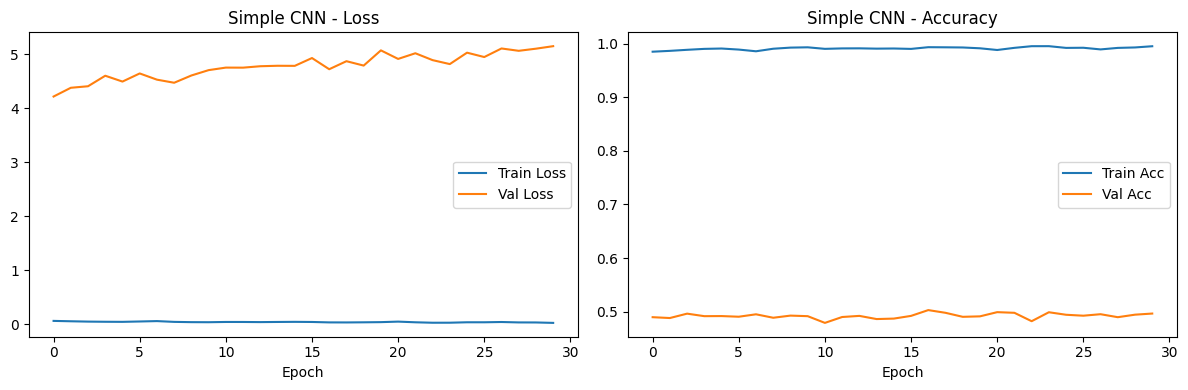

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/accuracy,▁▂▃▅▅▄▂▅▆▇▅▅▅▅▅▅▇▇▆▅▃▆██▆▆▄▆▆█
train/loss,█▇▆▅▅▆▇▅▄▃▄▄▄▄▅▄▃▃▃▄▅▃▂▂▃▃▄▃▂▁
val/accuracy,▄▄▆▅▅▄▆▄▅▅▁▄▅▃▃▅█▇▄▅▇▇▂▇▅▅▆▄▅▆
val/loss,▁▂▂▄▃▄▃▃▄▅▅▅▅▅▅▆▅▆▅▇▆▇▆▆▇▆█▇██
best_val_accuracy,0.50279
best_val_loss,4.21561
epoch,30
final_train_accuracy,0.99517
overfit_gap,0.49882
train/accuracy,0.99517


In [21]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_title('Simple CNN - Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs, label='Val Acc')
ax2.set_title('Simple CNN - Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()

wandb.log({"training_curves": wandb.Image(fig)})
plt.show()

wandb.summary["best_val_accuracy"] = max(val_accs)
wandb.summary["best_val_loss"] = min(val_losses)
wandb.summary["final_train_accuracy"] = train_accs[-1]
wandb.summary["overfit_gap"] = train_accs[-1] - val_accs[-1]

wandb.finish()

[simple-cnn-adam-lr0.001] Epoch 1/30 | Train Loss: 1.6732 Acc: 0.3336 | Val Loss: 1.5742 Acc: 0.3809
[simple-cnn-adam-lr0.001] Epoch 2/30 | Train Loss: 1.4802 Acc: 0.4306 | Val Loss: 1.4253 Acc: 0.4552
[simple-cnn-adam-lr0.001] Epoch 3/30 | Train Loss: 1.3559 Acc: 0.4812 | Val Loss: 1.3768 Acc: 0.4803
[simple-cnn-adam-lr0.001] Epoch 4/30 | Train Loss: 1.2664 Acc: 0.5190 | Val Loss: 1.3149 Acc: 0.5017
[simple-cnn-adam-lr0.001] Epoch 5/30 | Train Loss: 1.1805 Acc: 0.5539 | Val Loss: 1.3217 Acc: 0.5104
[simple-cnn-adam-lr0.001] Epoch 6/30 | Train Loss: 1.0914 Acc: 0.5908 | Val Loss: 1.3425 Acc: 0.5030
[simple-cnn-adam-lr0.001] Epoch 7/30 | Train Loss: 0.9938 Acc: 0.6291 | Val Loss: 1.3382 Acc: 0.5171
[simple-cnn-adam-lr0.001] Epoch 8/30 | Train Loss: 0.8754 Acc: 0.6762 | Val Loss: 1.3745 Acc: 0.5199
[simple-cnn-adam-lr0.001] Epoch 9/30 | Train Loss: 0.7551 Acc: 0.7276 | Val Loss: 1.4778 Acc: 0.4951
[simple-cnn-adam-lr0.001] Epoch 10/30 | Train Loss: 0.6321 Acc: 0.7718 | Val Loss: 1.5820 A

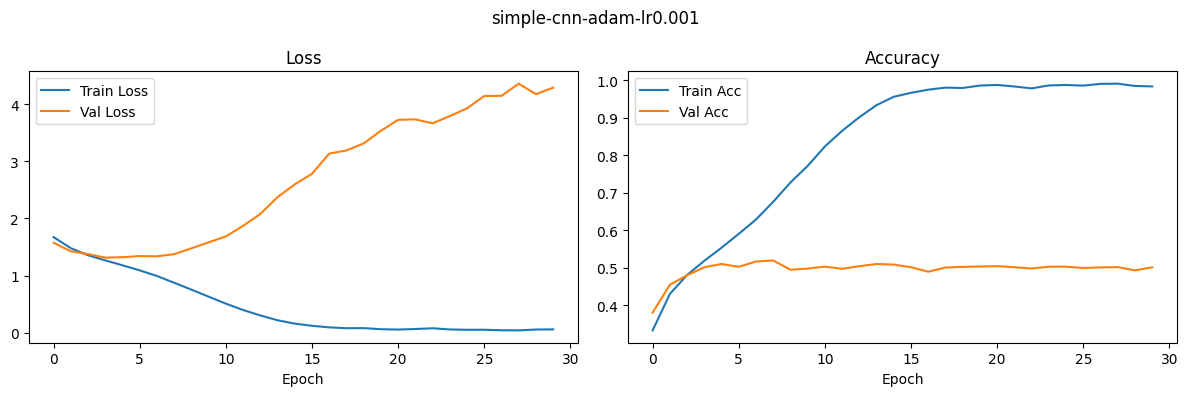

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/accuracy,▁▂▃▃▃▄▄▅▅▆▆▇▇▇████████████████
train/loss,█▇▇▆▆▆▅▅▄▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▅▆▇█▇██▇▇▇▇▇█▇▇▆▇▇▇▇▇▇▇▇▇▇▇▇▇
val/loss,▂▁▁▁▁▁▁▁▁▂▂▂▃▃▄▄▅▅▆▆▇▇▆▇▇█████
best_val_accuracy,0.51985
best_val_loss,1.31489
epoch,30
final_train_accuracy,0.98363
overfit_gap,0.48206
train/accuracy,0.98363



✅ Finished: simple-cnn-adam-lr0.001



[simple-cnn-adam-lr0.0001] Epoch 1/30 | Train Loss: 1.7579 Acc: 0.2790 | Val Loss: 1.6940 Acc: 0.3307
[simple-cnn-adam-lr0.0001] Epoch 2/30 | Train Loss: 1.6363 Acc: 0.3651 | Val Loss: 1.5966 Acc: 0.3776
[simple-cnn-adam-lr0.0001] Epoch 3/30 | Train Loss: 1.5706 Acc: 0.3968 | Val Loss: 1.5516 Acc: 0.4082
[simple-cnn-adam-lr0.0001] Epoch 4/30 | Train Loss: 1.5271 Acc: 0.4155 | Val Loss: 1.5224 Acc: 0.4232
[simple-cnn-adam-lr0.0001] Epoch 5/30 | Train Loss: 1.4908 Acc: 0.4301 | Val Loss: 1.4913 Acc: 0.4298
[simple-cnn-adam-lr0.0001] Epoch 6/30 | Train Loss: 1.4598 Acc: 0.4421 | Val Loss: 1.4678 Acc: 0.4465
[simple-cnn-adam-lr0.0001] Epoch 7/30 | Train Loss: 1.4315 Acc: 0.4530 | Val Loss: 1.4716 Acc: 0.4460
[simple-cnn-adam-lr0.0001] Epoch 8/30 | Train Loss: 1.4110 Acc: 0.4639 | Val Loss: 1.4408 Acc: 0.4565
[simple-cnn-adam-lr0.0001] Epoch 9/30 | Train Loss: 1.3806 Acc: 0.4776 | Val Loss: 1.4314 Acc: 0.4608
[simple-cnn-adam-lr0.0001] Epoch 10/30 | Train Loss: 1.3629 Acc: 0.4835 | Val Loss

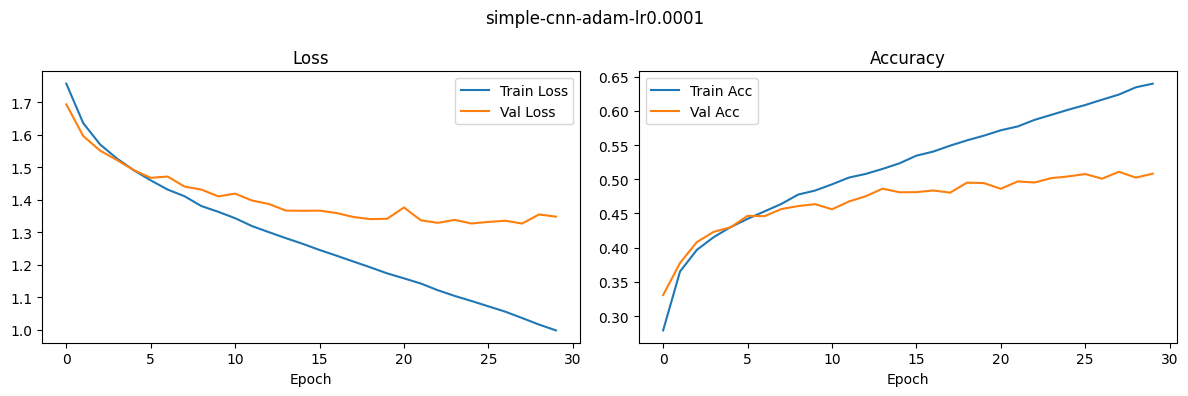

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/accuracy,▁▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇████
train/loss,█▇▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁
val/accuracy,▁▃▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████
val/loss,█▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▂▁▁▁▁▁▁▁▂▁
best_val_accuracy,0.51097
best_val_loss,1.32674
epoch,30
final_train_accuracy,0.63983
overfit_gap,0.13165
train/accuracy,0.63983



✅ Finished: simple-cnn-adam-lr0.0001



[simple-cnn-sgd-lr0.01] Epoch 1/30 | Train Loss: 1.7665 Acc: 0.2803 | Val Loss: 1.6579 Acc: 0.3460
[simple-cnn-sgd-lr0.01] Epoch 2/30 | Train Loss: 1.6452 Acc: 0.3549 | Val Loss: 1.5803 Acc: 0.3858
[simple-cnn-sgd-lr0.01] Epoch 3/30 | Train Loss: 1.5543 Acc: 0.3950 | Val Loss: 1.5077 Acc: 0.4234
[simple-cnn-sgd-lr0.01] Epoch 4/30 | Train Loss: 1.4634 Acc: 0.4390 | Val Loss: 1.4492 Acc: 0.4518
[simple-cnn-sgd-lr0.01] Epoch 5/30 | Train Loss: 1.3801 Acc: 0.4692 | Val Loss: 1.3999 Acc: 0.4707
[simple-cnn-sgd-lr0.01] Epoch 6/30 | Train Loss: 1.3013 Acc: 0.5057 | Val Loss: 1.3710 Acc: 0.4836
[simple-cnn-sgd-lr0.01] Epoch 7/30 | Train Loss: 1.2174 Acc: 0.5392 | Val Loss: 1.3467 Acc: 0.4904
[simple-cnn-sgd-lr0.01] Epoch 8/30 | Train Loss: 1.1371 Acc: 0.5736 | Val Loss: 1.3443 Acc: 0.4993
[simple-cnn-sgd-lr0.01] Epoch 9/30 | Train Loss: 1.0374 Acc: 0.6121 | Val Loss: 1.3033 Acc: 0.5118
[simple-cnn-sgd-lr0.01] Epoch 10/30 | Train Loss: 0.9170 Acc: 0.6642 | Val Loss: 1.3764 Acc: 0.5157
[simple-c

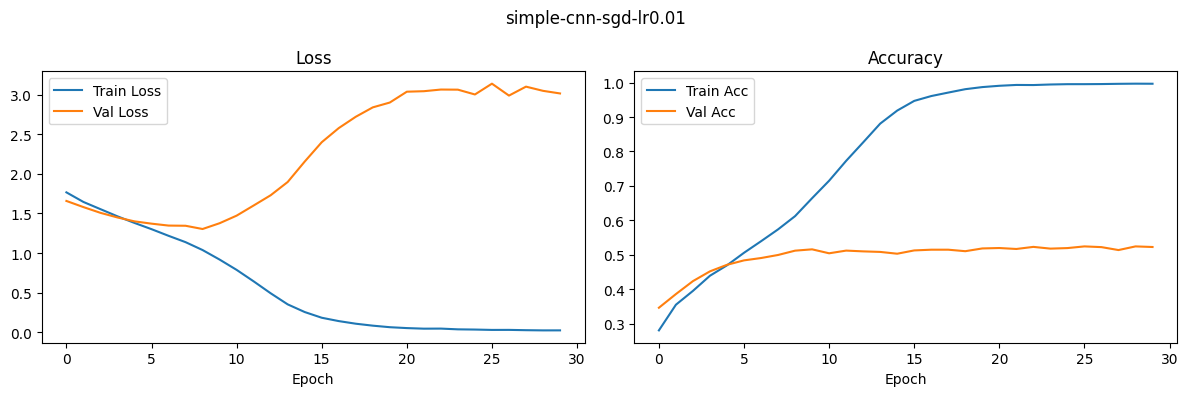

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/accuracy,▁▂▂▃▃▃▄▄▄▅▅▆▆▇▇███████████████
train/loss,██▇▇▆▆▆▅▅▅▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▃▄▅▆▆▇▇██▇█▇▇▇███▇███████████
val/loss,▂▂▂▂▁▁▁▁▁▁▂▂▃▃▄▅▆▆▇▇████▇█▇███
best_val_accuracy,0.52421
best_val_loss,1.30332
epoch,30
final_train_accuracy,0.99665
overfit_gap,0.47418
train/accuracy,0.99665



✅ Finished: simple-cnn-sgd-lr0.01



[simple-cnn-rmsprop-lr0.001] Epoch 1/30 | Train Loss: 1.7718 Acc: 0.3190 | Val Loss: 1.5505 Acc: 0.4070
[simple-cnn-rmsprop-lr0.001] Epoch 2/30 | Train Loss: 1.5071 Acc: 0.4217 | Val Loss: 1.4979 Acc: 0.4349
[simple-cnn-rmsprop-lr0.001] Epoch 3/30 | Train Loss: 1.3964 Acc: 0.4694 | Val Loss: 1.4620 Acc: 0.4319
[simple-cnn-rmsprop-lr0.001] Epoch 4/30 | Train Loss: 1.3070 Acc: 0.5053 | Val Loss: 1.3540 Acc: 0.4842
[simple-cnn-rmsprop-lr0.001] Epoch 5/30 | Train Loss: 1.2225 Acc: 0.5411 | Val Loss: 1.3449 Acc: 0.4970
[simple-cnn-rmsprop-lr0.001] Epoch 6/30 | Train Loss: 1.1399 Acc: 0.5718 | Val Loss: 1.3536 Acc: 0.4883
[simple-cnn-rmsprop-lr0.001] Epoch 7/30 | Train Loss: 1.0469 Acc: 0.6121 | Val Loss: 1.3381 Acc: 0.5045
[simple-cnn-rmsprop-lr0.001] Epoch 8/30 | Train Loss: 0.9441 Acc: 0.6551 | Val Loss: 1.3917 Acc: 0.5057
[simple-cnn-rmsprop-lr0.001] Epoch 9/30 | Train Loss: 0.8399 Acc: 0.6942 | Val Loss: 1.4596 Acc: 0.5017
[simple-cnn-rmsprop-lr0.001] Epoch 10/30 | Train Loss: 0.7351 Ac

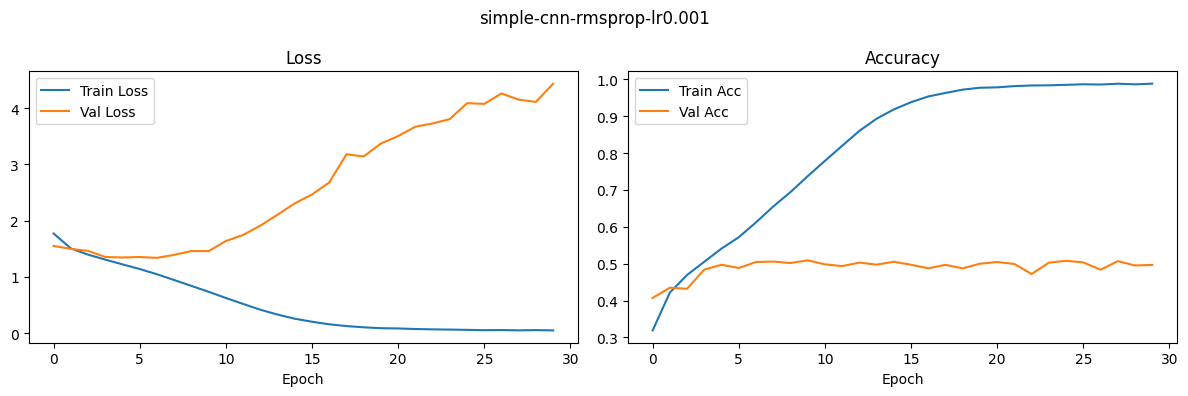

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/accuracy,▁▂▃▃▃▄▄▅▅▅▆▆▇▇▇▇██████████████
train/loss,█▇▆▆▆▅▅▅▄▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▃▃▆▇▇██▇█▇▇█▇█▇▇▇▇▇█▇▅███▆█▇▇
val/loss,▁▁▁▁▁▁▁▁▁▁▂▂▂▃▃▄▄▅▅▆▆▆▆▇▇▇█▇▇█
best_val_accuracy,0.50906
best_val_loss,1.3381
epoch,30
final_train_accuracy,0.98842
overfit_gap,0.49173
train/accuracy,0.98842



✅ Finished: simple-cnn-rmsprop-lr0.001



[simple-cnn-adam-batch128] Epoch 1/30 | Train Loss: 1.7042 Acc: 0.3162 | Val Loss: 1.5877 Acc: 0.3786
[simple-cnn-adam-batch128] Epoch 2/30 | Train Loss: 1.5259 Acc: 0.4130 | Val Loss: 1.4746 Acc: 0.4387
[simple-cnn-adam-batch128] Epoch 3/30 | Train Loss: 1.4001 Acc: 0.4633 | Val Loss: 1.4086 Acc: 0.4639
[simple-cnn-adam-batch128] Epoch 4/30 | Train Loss: 1.3015 Acc: 0.5062 | Val Loss: 1.3547 Acc: 0.4788
[simple-cnn-adam-batch128] Epoch 5/30 | Train Loss: 1.2160 Acc: 0.5395 | Val Loss: 1.3158 Acc: 0.5002
[simple-cnn-adam-batch128] Epoch 6/30 | Train Loss: 1.1293 Acc: 0.5734 | Val Loss: 1.3221 Acc: 0.5010
[simple-cnn-adam-batch128] Epoch 7/30 | Train Loss: 1.0360 Acc: 0.6148 | Val Loss: 1.2983 Acc: 0.5152
[simple-cnn-adam-batch128] Epoch 8/30 | Train Loss: 0.9373 Acc: 0.6552 | Val Loss: 1.3114 Acc: 0.5193
[simple-cnn-adam-batch128] Epoch 9/30 | Train Loss: 0.8207 Acc: 0.7042 | Val Loss: 1.3416 Acc: 0.5280
[simple-cnn-adam-batch128] Epoch 10/30 | Train Loss: 0.7009 Acc: 0.7505 | Val Loss

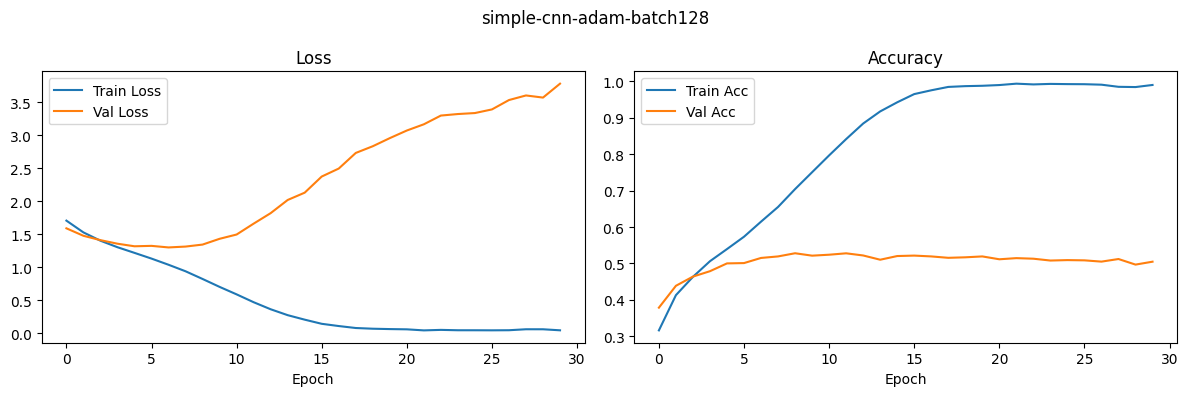

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/accuracy,▁▂▃▃▃▄▄▅▅▅▆▆▇▇▇███████████████
train/loss,█▇▇▆▆▆▅▅▄▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▄▅▆▇▇▇██████▇███▇▇█▇▇▇▇▇▇▇▇▇▇
val/loss,▂▁▁▁▁▁▁▁▁▁▂▂▂▃▃▄▄▅▅▆▆▆▇▇▇▇▇▇▇█
best_val_accuracy,0.52804
best_val_loss,1.29828
epoch,30
final_train_accuracy,0.99012
overfit_gap,0.48524
train/accuracy,0.99012



✅ Finished: simple-cnn-adam-batch128



In [23]:
from torch.optim import SGD, RMSprop

experiments = [
    {
        "name": "simple-cnn-adam-lr0.001",
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "batch_size": 64,
        "epochs": 30,
    },
    {
        "name": "simple-cnn-adam-lr0.0001",
        "learning_rate": 0.0001,
        "optimizer": "Adam",
        "batch_size": 64,
        "epochs": 30,
    },
    {
        "name": "simple-cnn-sgd-lr0.01",
        "learning_rate": 0.01,
        "optimizer": "SGD",
        "batch_size": 64,
        "epochs": 30,
    },
    {
        "name": "simple-cnn-rmsprop-lr0.001",
        "learning_rate": 0.001,
        "optimizer": "RMSprop",
        "batch_size": 64,
        "epochs": 30,
    },
    {
        "name": "simple-cnn-adam-batch128",
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "batch_size": 128,
        "epochs": 30,
    },
]

def get_optimizer(name, model, lr):
    if name == "Adam":
        return Adam(model.parameters(), lr=lr)
    elif name == "SGD":
        return SGD(model.parameters(), lr=lr, momentum=0.9)
    elif name == "RMSprop":
        return RMSprop(model.parameters(), lr=lr)

def run_experiment(config):
    run = wandb.init(
        project="Facial_Expression_Recognition",
        name=config["name"],
        group="simple-cnn",
        tags=["simple-cnn", "baseline", config["optimizer"].lower()],
        config={
            **config,
            "architecture": "SimpleCNN",
            "num_conv_layers": 2,
            "conv_filters": [32, 64],
            "fc_units": 256,
            "batch_norm": False,
            "dropout": False,
            "dataset": "FER2013"
        }
    )

    model = SimpleCNN().to(device)
    optimizer = get_optimizer(config["optimizer"], model, config["learning_rate"])
    criterion = nn.CrossEntropyLoss()

    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False)

    wandb.watch(model, log="all", log_freq=10)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(config["epochs"]):
        # --- Train ---
        model.train()
        total_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total

        model.eval()
        total_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                total_loss += loss.item()
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)

        val_loss = total_loss / len(val_loader)
        val_acc  = correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        wandb.log({
            "epoch": epoch + 1,
            "train/loss": train_loss,
            "train/accuracy": train_acc,
            "val/loss": val_loss,
            "val/accuracy": val_acc,
        })

        print(f"[{config['name']}] Epoch {epoch+1}/{config['epochs']} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(config["name"])

    ax1.plot(train_losses, label='Train Loss')
    ax1.plot(val_losses, label='Val Loss')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    ax2.plot(train_accs, label='Train Acc')
    ax2.plot(val_accs, label='Val Acc')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.legend()

    plt.tight_layout()
    wandb.log({"training_curves": wandb.Image(fig)})
    plt.show()
    plt.close(fig)

    wandb.summary["best_val_accuracy"]    = max(val_accs)
    wandb.summary["best_val_loss"]        = min(val_losses)
    wandb.summary["final_train_accuracy"] = train_accs[-1]
    wandb.summary["overfit_gap"]          = train_accs[-1] - val_accs[-1]

    wandb.finish()
    print(f"\n✅ Finished: {config['name']}\n{'='*60}\n")

for config in experiments:
    run_experiment(config)